## 1) Import libraries and variables

In [2]:

import os
import importlib 
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from clustering_helpers import get_best_config, build_membership_features, variance_of_means
from config import (
    INPUT_DATA_PATH,
    VALIDATION_RESULTS_PATH,
    VARIANCE_OF_MEANS_PATH,
    ENCODED_MEMBERSHIP_PATH,
    MEMBERSHIP_PATH,
    PLOTS_DIR,
    labels_path
)

print(f"Config loaded.")

# Create plots directory
os.makedirs(PLOTS_DIR, exist_ok=True)

Config loaded. USE_SYNTHETIC_INPUTS: False


## 2) Load best config & wp3 data

In [8]:
best_config = get_best_config(VALIDATION_RESULTS_PATH)
print(f"Best configuration: {best_config}")

labels_df = pd.read_csv(labels_path(best_config), compression="gzip")
wp3_df = pd.read_csv(INPUT_DATA_PATH)
df = wp3_df.merge(labels_df, on="patient_id", how="inner")
del wp3_df, labels_df
print(f"Merged {len(df)} patients with cluster labels")
display(df.head())


Best configuration: raw_optics
Merged 1165 patients with cluster labels


,patient_id,sex,patient_index_date,practice_deregistration_date,death_date,household_size,prostate_cancer,pregnancy,hrtcocp,hf_exclude_date,...,homeless,housebound,birth_date,ethnicity_cat,cat_diabetes,gestationaldm_date,t2dm_date,t1dm_date,otherdm_date,cluster
0,32,female,2019-02-01,NaN,NaN,3553.0,NaN,NaN,NaN,NaN,...,False,False,1937-10-01,White,DM unlikely,NaN,NaN,NaN,NaN,0
1,58,male,2019-02-01,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,False,False,1962-12-01,Unknown,DM unlikely,NaN,NaN,NaN,NaN,0
2,66,female,2019-02-01,NaN,2021-09-01,NaN,NaN,NaN,NaN,NaN,...,False,False,1962-04-01,Unknown,T1DM,NaN,NaN,2021-04-27,NaN,3
3,71,male,2019-02-01,NaN,2023-12-09,NaN,NaN,NaN,NaN,NaN,...,False,False,1933-12-01,Unknown,DM unlikely,NaN,NaN,NaN,NaN,3
4,127,female,2019-02-01,NaN,NaN,19004.0,NaN,NaN,NaN,NaN,...,False,False,1942-07-01,White,DM unlikely,NaN,NaN,NaN,NaN,0


## 3) Build membership features

In [9]:

membership = build_membership_features(df)
print(f"Built {len(membership.columns)-1} membership features")
display(membership.head())
# Define output directory from VARIANCE_OF_MEANS_PATH
output_dir = os.path.dirname(VARIANCE_OF_MEANS_PATH)
os.makedirs(output_dir, exist_ok=True)

membership.to_csv(MEMBERSHIP_PATH, index=False, compression="gzip")
print(f"Saved membership features")


Built 34 membership features


,patient_id,diagnosis_community,diagnosis_emergency,age_band,cat_household_size,sex,ethnicity_cat,imd_quintile,region,rural_urban,...,has_diabetes,mltc_count,has_mltc,carehome_at_index,housebound,smi,homeless,substance_abuse,migrant,non_english_speaking
0,32,0,1,80-84,>=3,female,White,unknown,NaN,NaN,...,0,2,1,0,0,0,0,0,1,0
1,58,0,1,55-59,unknown,male,Unknown,2,NaN,1.0,...,0,1,0,1,0,0,0,0,1,0
2,66,0,1,55-59,unknown,female,Unknown,unknown,South East,NaN,...,1,2,1,0,0,0,0,0,1,0
3,71,0,1,85-89,unknown,male,Unknown,unknown,London,NaN,...,0,1,0,0,0,0,0,0,0,0
4,127,0,1,75-79,>=3,female,White,unknown,East Midlands,NaN,...,0,2,1,0,0,0,0,0,0,0


Saved membership features


## 4) One-hot encoded features


In [10]:
# One-hot encode categorical variables
X = pd.get_dummies(membership.drop(columns="patient_id"), dummy_na=True, drop_first=False)
display(X.head())
# Identify continuous vs dummy columns
continuous_cols = [col for col in X.columns if col in ['mltc_count']]
dummy_cols = [col for col in X.columns if col not in continuous_cols]

print(f"After one-hot encoding: {len(X.columns)} features "
        f"({len(continuous_cols)} continuous, {len(dummy_cols)} dummy)")

# Set type to int
for col in dummy_cols:
    if col in X.columns:
        X[col] = X[col].astype(int)

# Remove continuous variables
X = X.drop(columns=[col for col in continuous_cols if col in X.columns])

# Re_attach patient_id
X_with_id = pd.concat([
    membership[["patient_id"]].reset_index(drop=True),
    X.reset_index(drop=True)
], axis=1)

X_with_id.to_csv(ENCODED_MEMBERSHIP_PATH, index=False, compression="gzip")
print(f"Saved one-hot encoded features with patient_id")
del X_with_id  


,diagnosis_community,diagnosis_emergency,copd_preexisting,copd_new,hypertension_preexisting,hypertension_new,af_preexisting,af_new,ihd_preexisting,ihd_new,...,rural_urban_8.0,rural_urban_nan,cat_diabetes_DM unlikely,cat_diabetes_DM_other,cat_diabetes_GDM,cat_diabetes_T1DM,cat_diabetes_T2DM,cat_diabetes_nan,smoking_N,smoking_nan
0,0,1,0,0,0,0,0,0,0,1,...,False,True,True,False,False,False,False,False,True,False
1,0,1,0,0,0,0,0,0,0,1,...,False,False,True,False,False,False,False,False,True,False
2,0,1,0,0,1,0,0,0,0,0,...,False,True,False,False,False,True,False,False,True,False
3,0,1,0,0,1,0,0,0,0,0,...,False,True,True,False,False,False,False,False,True,False
4,0,1,0,0,0,0,0,0,0,1,...,False,True,True,False,False,False,False,False,True,False


After one-hot encoding: 86 features (1 continuous, 85 dummy)
Saved one-hot encoded features with patient_id


## 5) Compute variance-of-means

In [11]:
# Calculate variance of means
vom = variance_of_means(df["cluster"], X)
vom_sorted = vom.sort_values(ascending=False)
vom_sorted.to_csv(VARIANCE_OF_MEANS_PATH, header=["variance_of_means"])
print(f"\nSaved")



Saved


## 6) Plot variance of means for each feature

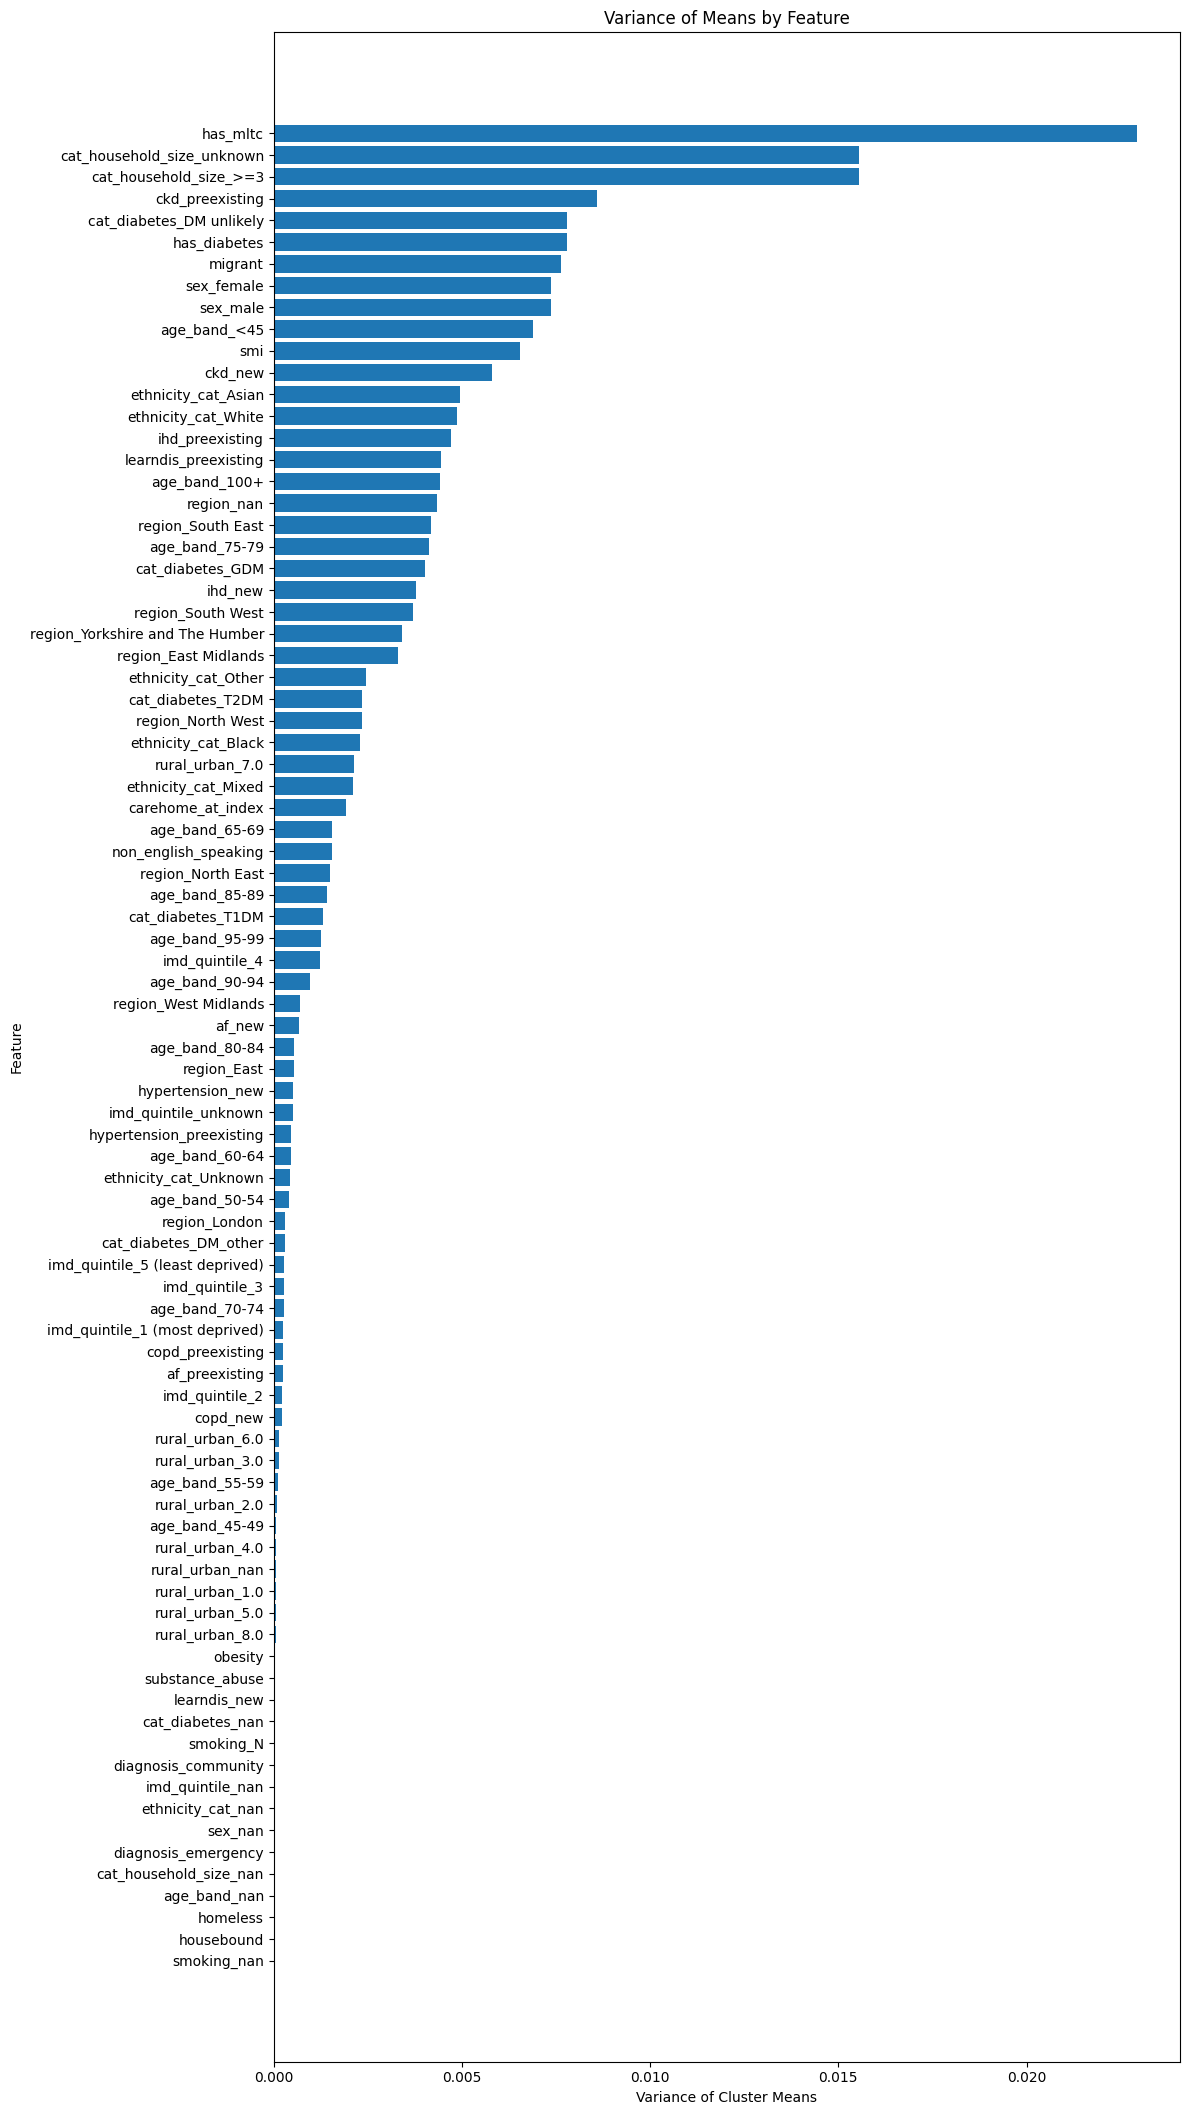

Saved plot


In [12]:
# Plot all variance-of-means values
fig_height = max(6, 0.25 * len(vom_sorted))
fig, ax = plt.subplots(figsize=(12, fig_height))
ax.barh(vom_sorted.index, vom_sorted.values, color="#1f77b4")
ax.invert_yaxis()
ax.set_title("Variance of Means by Feature")
ax.set_xlabel("Variance of Cluster Means")
ax.set_ylabel("Feature")
fig.tight_layout()

vom_plot_path = os.path.join(PLOTS_DIR, "vom_figure.png")
fig.savefig(vom_plot_path, dpi=200, bbox_inches="tight")
plt.show()
plt.close(fig)
print(f"Saved plot")
